# 🧠 Анализ тональности комментариев

## 🎯 Цель проекта

Разработка нейросети для автоматического определения тональности текстовых комментариев.

##  🔧 Импорт библиотек

In [52]:
# Стандартные библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Нейросети
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from keras.models import Model
from tensorflow.keras.models import Sequential
from keras.layers import Input, Dense, Embedding, Dropout, SpatialDropout1D, concatenate, Conv1D, MaxPooling1D
from keras.layers import LSTM, GRU, Bidirectional, GlobalAveragePooling1D, GlobalMaxPooling1D, Flatten, Attention
from tensorflow.keras.preprocessing import text, sequence
from keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from string import punctuation
import pymorphy2
import re

# Машинное обучение
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Метрики
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    f1_score, precision_score, recall_score, 
    accuracy_score, roc_auc_score, roc_curve
)

# Дополнительные инструменты
from scikeras.wrappers import KerasClassifier
from gensim.models import FastText, KeyedVectors

# Ошибки
import warnings
warnings.simplefilter('ignore')

## 📥 Загрузка наборов данных

### **Описание первого набора данных `labeled.csv`**<br>
Небольшой набор данных с размеченными комментариями с сайтов 2ch.hk и pikabu.ru.<br>
[Ссылка на набор данных](https://www.kaggle.com/datasets/blackmoon/russian-language-toxic-comments/data)

In [2]:
df_toxic = pd.read_csv('labeled.csv')

In [3]:
df_toxic.head(10)

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0
5,Для каких стан является эталоном современная с...,1.0
6,В шапке были ссылки на инфу по текущему фильму...,0.0
7,УПАД Т! ТАМ НЕЛЬЗЯ СТРОИТЬ! ТЕХНОЛОГИЙ НЕТ! РА...,1.0
8,"Ебать тебя разносит, шизик.\n",1.0
9,"Обосрался, сиди обтекай\n",1.0


### 📊 Описание столбцов датасета<br>
| Столбец | Описание |
|---------|----------|
| `comment` | Текст комментария |
| `toxic` | Токсичен ли комментарий |

---

### **Описание второго набора данных `women-clothing-accessories.3-class.balanced.csv`**<br>
Набор данных для анализа настроений в отзывах о товарах на русском языке.<br>
[Ссылка на набор данных](https://github.com/sismetanin/rureviews/tree/master)

In [4]:
df_reviews = pd.read_csv(
    'women-clothing-accessories.3-class.balanced.csv',
    sep='\t',
    encoding='utf-8'
)

In [5]:
df_reviews.head(10)

,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative
5,Очень глубокие проймы,negative
6,Я недовольна заказом.Я вот одного не понимаю п...,negative
7,"заказала размер s на от 64,об 94,начнем с того...",negative
8,Заказ я сделала в июле. С тех пор посылка отсл...,negative
9,Ужасное качество товара!,negative


### 📊 Описание столбцов датасета<br>
| Столбец | Описание |
|---------|----------|
| `review` | Текст комментария |
| `sentiment` | Тональность комментария |

## 🔍 Анализ наборов данных

In [6]:
df_toxic.shape

(14412, 2)

In [7]:
df_reviews.shape

(90000, 2)

### Размеры датасетов
* **df_toxic** — 14412 строк и 2 столбца;
* **df_reviews** — 90000 строк и 2 столбца.

In [8]:
df_toxic.iloc[:, 1].unique()

array([1., 0.])

In [9]:
df_reviews.iloc[:, 1].unique()

array(['negative', 'neautral', 'positive'], dtype=object)

### Уникальные значения
* **df_toxic:**
  + **0** — не токсичный;
  + **1** — токсичный.
* **df_reviews:**
  + **negative** — негативный;
  + **neautral** — нейтральный;
  + **positive** — позитивный.

In [10]:
print(df_reviews.isnull().sum())

review       0
sentiment    0
dtype: int64


In [11]:
duplicates = df_reviews.duplicated().sum()
print(duplicates)
print(duplicates/len(df_reviews)*100)

2250
2.5


In [12]:
df_reviews = df_reviews.drop_duplicates()

In [13]:
duplicates = df_reviews.duplicated().sum()
print(duplicates)

0


In [14]:
df_reviews = df_reviews.rename(columns={'review': 'comment'})

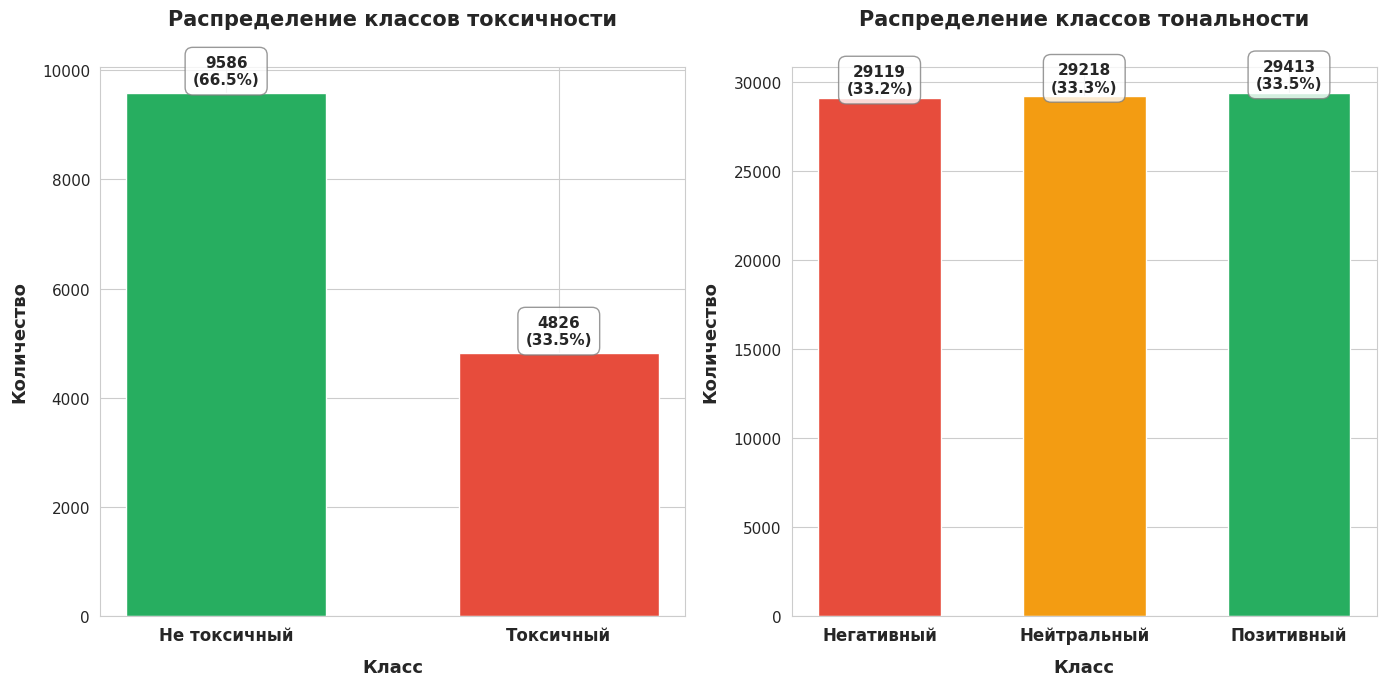

In [15]:
# Подсчет количества примеров в каждом классе

# Стили
sns.set_style("whitegrid")
sns.set_palette("deep")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

toxic_counts = df_toxic['toxic'].value_counts().sort_index()
sentiment_counts = df_reviews['sentiment'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Токсичность
bars1 = ax1.bar(toxic_counts.index, toxic_counts.values, 
                color=['#27ae60', '#e74c3c'], width=0.6)

ax1.set_xlabel('Класс', fontsize=13, fontweight='bold', labelpad=10)
ax1.set_ylabel('Количество', fontsize=13, fontweight='bold', labelpad=10)
ax1.set_title('Распределение классов токсичности', fontsize=15, fontweight='bold', pad=30)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Не токсичный', 'Токсичный'], fontsize=12, fontweight='bold')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height)}\n({height/len(df_toxic)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# Тональность
bars2 = ax2.bar(sentiment_counts.index, sentiment_counts.values, 
                color=['#e74c3c', '#f39c12', '#27ae60'], width=0.6)

ax2.set_xlabel('Класс', fontsize=13, fontweight='bold', labelpad=10)
ax2.set_ylabel('Количество', fontsize=13, fontweight='bold', labelpad=10)
ax2.set_title('Распределение классов тональности', fontsize=15, fontweight='bold', pad=30)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Негативный', 'Нейтральный', 'Позитивный'], fontsize=12, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height)}\n({height/len(df_reviews)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

## ♻️ Лемматизация и обработка текста

In [16]:
df_toxic_old = df_toxic.copy()
df_reviews_old = df_reviews.copy()

In [17]:
# Инициализация русских стоп слов
nltk.download('stopwords')
sw = stopwords.words("russian")

# Метод очистки текста
def clean_text(text):
    if not isinstance(text, str) or len(text.strip()) == 0: # проверка на пустую строку
        return ""
    
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"
                               u"\U0001F300-\U0001F5FF"
                               u"\U0001F680-\U0001F6FF"
                               u"\U0001F1E0-\U0001F1FF"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text) # удаление эмоджи
    
    text = re.sub(r'<[^>]+>', '', text) # удаляем html теги
    
    text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', 'URL', text) # удаление ссылки
    
#     text = text.replace("ё", "е").replace("Ё", "Е")
    
#     text = re.sub(r'[^a-zA-Zа-яА-ЯёЁ]+', ' ', text) # удаление всего кроме текста
    
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    
#     words = text.split() 
#     words = [word.lower() for word in words if word.lower() not in sw] #удаление стоп слов и приведение к нижнему регистру
    
#     text = " ".join(words) # преобразуем массив в строку
    
    text = text.lower()
    
    text = re.sub(r' +', ' ', text) # удаляем лишние пробелы
    
    return text.strip()

df_toxic['comment'] = df_toxic["comment"].apply(clean_text)
df_reviews['comment'] = df_reviews["comment"].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/devastated/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
# Метод токенизации
def tokenize_text(text):
    tokenized_text = word_tokenize(text, language='russian')

    return tokenized_text

df_toxic['comment'] = df_toxic['comment'].apply(lambda x: tokenize_text(x))
df_reviews['comment'] = df_reviews['comment'].apply(lambda x: tokenize_text(x))

In [19]:
# # Инициализация pymorphy
# morph = pymorphy2.MorphAnalyzer()

# # Метод лемматизации
# def lemmatize(text: list) -> list:
#     lemmas = [morph.parse(token)[0].normal_form for token in text]

#     return lemmas

# df_toxic['comment'] = df_toxic['comment'].apply(lambda x: lemmatize(x))
# df_reviews['comment'] = df_reviews['comment'].apply(lambda x: lemmatize(x))

In [20]:
def comments(df, name):
    print(f'\033[1mНабор данных: {name}\033[0m')
    for i in range(0,2):
        comment = df['comment'][i]
        print(f'Комментарий {i}: {comment}')

print(f'\033[1mКомментарии до обработки:\033[0m')
comments(df_toxic_old, "Токсичность")
comments(df_reviews_old, "Тональность")
print('\n==============================================================================================================\n')
print(f'\033[1mКомментарии после обработки:\033[0m')
comments(df_toxic, "Токсичность")
comments(df_reviews, "Тональность")

Комментарии до обработки:
Набор данных: Токсичность
Комментарий 0: Верблюдов-то за что? Дебилы, бл...

Комментарий 1: Хохлы, это отдушина затюканого россиянина, мол, вон, а у хохлов еще хуже. Если бы хохлов не было, кисель их бы придумал.

Набор данных: Тональность
Комментарий 0: качество плохое пошив ужасный (горловина наперекос) Фото не соответствует Ткань ужасная рисунок блеклый маленький рукав не такой УЖАС!!!!! не стоит за такие деньги г.......
Комментарий 1: Товар отдали другому человеку, я не получила посылку. Ладно хоть деньги вернули.


Комментарии после обработки:
Набор данных: Токсичность
Комментарий 0: ['верблюдов-то', 'за', 'что', '?', 'дебилы', ',', 'бл', '.']
Комментарий 1: ['хохлы', ',', 'это', 'отдушина', 'затюканого', 'россиянина', ',', 'мол', ',', 'вон', ',', 'а', 'у', 'хохлов', 'еще', 'хуже', '.', 'если', 'бы', 'хохлов', 'не', 'было', ',', 'кисель', 'их', 'бы', 'придумал', '.']
Набор данных: Тональность
Комментарий 0: ['качество', 'плохое', 'пошив', 'ужасный', '(', 

## ⚙️ Подготовка к обучению нейросети

In [21]:
df_toxic['comment'] = df_toxic['comment'].apply(lambda x: ' '.join(x))
df_reviews['comment'] = df_reviews['comment'].apply(lambda x: ' '.join(x))

In [22]:
tox_len = df_toxic['comment'].apply(lambda x: len(x.split()))
rev_len = df_reviews['comment'].apply(lambda x: len(x.split()))

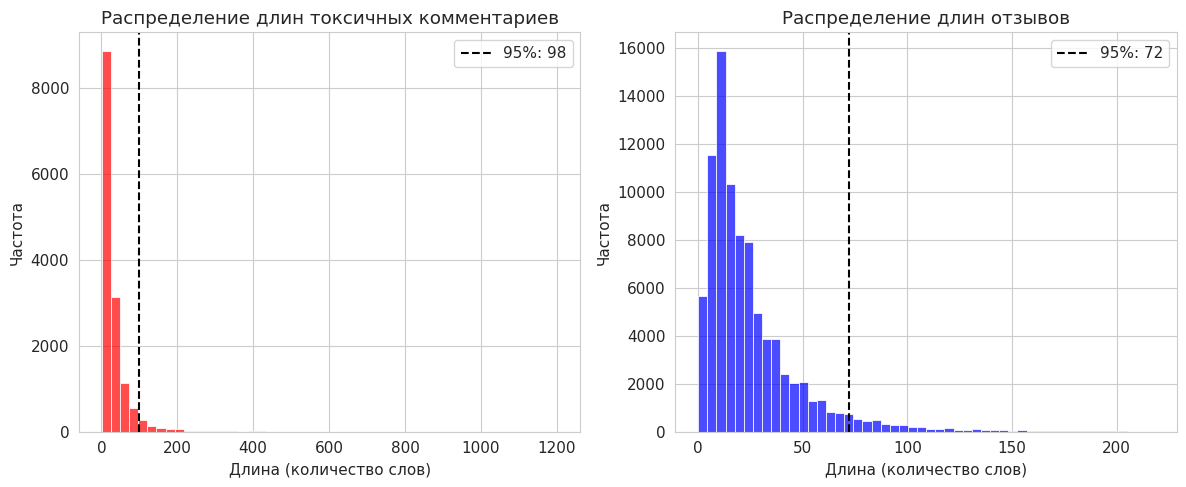

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(tox_len, bins=50, color='red', alpha=0.7)
plt.title('Распределение длин токсичных комментариев')
plt.xlabel('Длина (количество слов)')
plt.ylabel('Частота')
plt.axvline(tox_len.quantile(0.95), color='black', linestyle='--', label=f'95%: {tox_len.quantile(0.95):.0f}')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(rev_len, bins=50, color='blue', alpha=0.7)
plt.title('Распределение длин отзывов')
plt.xlabel('Длина (количество слов)')
plt.ylabel('Частота')
plt.axvline(rev_len.quantile(0.95), color='black', linestyle='--', label=f'95%: {rev_len.quantile(0.95):.0f}')
plt.legend()

plt.tight_layout()
plt.show()

Можем заметить что большинство комментариев имеют длину до 50 слов.<br>
<br>
**95 процентиль комментариев:**<br>
  + **df_toxic** — 50 слов;
  + **df_reviews** — 38 слов.

In [24]:
tox_len.quantile(0.95)

np.float64(98.0)

In [25]:
maxlen = max(tox_len.quantile(0.95), rev_len.quantile(0.95), 50).astype(int)
char_avg = df_reviews['comment'].str.len()
word_avg = df_reviews['comment'].str.split().str.len()

print(f'Средняя длина в символах: {char_avg.mean():.2f}')
print(f'Средняя длина в словах: {word_avg.mean():.2f}')
print(f'Максимальная длинна комментария: {maxlen}')

Средняя длина в символах: 136.37
Средняя длина в словах: 25.25
Максимальная длинна комментария: 98


In [26]:
# Объединение комментариев датасетов
all_texts = pd.concat([df_toxic['comment'], df_reviews['comment']])

In [27]:
# Cоздание словаря
tokenizer = text.Tokenizer()
tokenizer.fit_on_texts(all_texts)

In [28]:
vocab_size = len(tokenizer.word_index) + 1
print(f"Размер словаря: {vocab_size} слов")

Размер словаря: 104460 слов


In [29]:
print("\nСамые частые слова:")
for word, index in list(tokenizer.word_index.items())[:10]:
    print(f"  {word}: {index}")


Самые частые слова:
  не: 1
  на: 2
  и: 3
  в: 4
  очень: 5
  но: 6
  что: 7
  размер: 8
  с: 9
  как: 10


### 📊 Почему именно эти слова самые частые?<br>
* **\<OOV>** - специальный токен для слов вне словаря (out-of-vocabulary), всегда имеет индекс 1 при oov_token='\<OOV>';
* **очень** - очень частое наречие в отзывах "очень хороший", "очень плохой", "очень большой" и т.д;
* **размер** - ключевое слово для одежды и аксессуаров "размер не подошел", "размер маломерит", "размер 42" и т.д;
* **продавец** - часто упоминается в отзывах "продавец не отвечает", "продавец помог", "продавец обманул";
* **прийти** - о доставке товара "товар не пришел", "посылка пришла", "заказ пришел";
* **качество** - главное в отзывах "качество плохое", "качество отличное", "качество ужасное";
* **деньга** - лемматизированная форма "деньги" "деньги потрачены зря", "деньги на ветер", "стоит своих денег";
* **товар** - самое частое существительное "товар хороший", "товар не соответствует", "товар пришел";
* **это** - самое частое местоимение в русском языке "это ужасно", "это хорошо", "это нормально";
* **хороший** - ключевое оценочное слово "хороший товар", "хорошее качество", "хороший продавец".

In [30]:
y_toxic = df_toxic['toxic'].values.astype(int)

In [45]:
texts_rev = df_reviews['comment'].values
labels_rev = df_reviews['sentiment'].values

In [47]:
max_features = 30000

tokenizer = text.Tokenizer(num_words=max_features, oov_token='<OOV>')
tokenizer.fit_on_texts(texts_rev)

sequences = tokenizer.texts_to_sequences(texts_rev)

X = sequence.pad_sequences(sequences, maxlen=maxlen)

Y = labels_rev

In [48]:
skf_rev = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [49]:
embed_size = 300

In [50]:
EMBEDDING_FILE = 'cc.ru.300.vec'

def get_coefs(word, *arr): 
    return word, np.asarray(arr, dtype='float32')

embeddings_index = dict(get_coefs(*o.rstrip().rsplit(' ')) for o in open(EMBEDDING_FILE, encoding='utf-8'))

word_index = tokenizer.word_index
nb_words = min(max_features, len(word_index)) + 1
embedding_matrix = np.zeros((nb_words, embed_size))
for word, i in word_index.items():
    if i >= max_features: continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None: embedding_matrix[i] = embedding_vector

In [51]:
# Проверка, какой процент слов покрыт эмбеддингами
words_in_vocab = len(tokenizer.word_index)
words_with_embeddings = np.sum(np.sum(embedding_matrix, axis=1) != 0)

print(f"Всего слов в словаре: {words_in_vocab}")
print(f"Слов с эмбеддингами: {words_with_embeddings}")
print(f"Процент покрытия: {words_with_embeddings/words_in_vocab*100:.2f}%")

# Также проверьте для тестовой выборки
max_index = np.max(rev_feature_train)
print(f"Максимальный индекс в данных: {max_index}")
print(f"Размер embedding матрицы: {embedding_matrix.shape[0]}")

Всего слов в словаре: 53963
Слов с эмбеддингами: 27151
Процент покрытия: 50.31%
Максимальный индекс в данных: 51085
Размер embedding матрицы: 30001


In [ ]:
sd

In [ ]:
# Модель для тональности lstm
def create_sentiment_model_lstm_gird(learn_rate=0.001, dropout_rate=0.2, optimizer='adam', lstm_units=80, **kwargs):
    inp = Input(shape=(maxlen, ))
    
    x = Embedding(nb_words, embed_size, weights=[embedding_matrix])(inp)
    x = SpatialDropout1D(dropout_rate)(x)
    
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    x = Dropout(dropout_rate)(x)
    
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    conc = concatenate([avg_pool, max_pool])
    
    x = Dense(64, activation='relu')(conc)
    x = Dropout(dropout_rate)(x)
    
    outp = Dense(3, activation="softmax")(x
                                         )
    model = Model(inputs=inp, outputs=outp)
    
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learn_rate)
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learn_rate)
    elif optimizer == 'adamax':
        opt = tf.keras.optimizers.Adamax(learning_rate=learn_rate)
    
    model.compile(loss='categorical_crossentropy',
                         optimizer=opt,
                         metrics=['accuracy'])
    
    return model

In [ ]:
%%time
seed = 7
np.random.seed(seed)
model = KerasClassifier(build_fn = create_sentiment_model_lstm_gird, verbose=1)

param_grid = {
    'batch_size': [32,40,50],
    'epochs': [3,4,5],
    'model__learn_rate': [0.0001,0.001,0.01,0.1],
    'model__dropout_rate': [0.0, 0.1, 0.2, 0.3, 0.4], 
    'model__optimizer': ['sgd', 'adam', 'adamax']
}
#Grid search for best parameter
grid = GridSearchCV(estimator = model, param_grid = param_grid, cv = 3, error_score='raise')

grid_result = grid.fit(X_s_train[:3000], y_s_train[:3000])

In [ ]:
# print result of grid search
print("Top score: %f by using %s" % (grid_result.best_score_, grid_result.best_params_))
print()

top_optimizer = grid_result.best_params_.get('model__optimizer')
top_batch_size = grid_result.best_params_.get('batch_size') 
top_epochs = grid_result.best_params_.get('epochs') 
top_learning_rate = grid_result.best_params_.get('model__learn_rate')
top_dropout_rate = grid_result.best_params_.get('model__dropout_rate')

print(f'{top_optimizer}, {top_batch_size}, {top_epochs}, {top_learning_rate}, {top_dropout_rate}')

In [ ]:
# Модель для тональности lstm
def create_sentiment_model_lstm(learn_rate=0.001, dropout_rate=0.1, lstm_units=64, 
                               nb_words=None, embed_size=None, embedding_matrix=None):
    inp = Input(shape=(maxlen, ))
    
    x = Embedding(nb_words, embed_size, trainable=False, weights=[embedding_matrix])(inp)
    
    x = Bidirectional(LSTM(lstm_units, return_sequences=False))(x)
    
    x = Dense(16, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    
    outp = Dense(3, activation="softmax")(x)
    model = Model(inputs=inp, outputs=outp)
    
    model.compile(loss='categorical_crossentropy',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=learn_rate),
                         metrics=['accuracy'])
    
    return model

# Модель для тональности Bilstm
def create_sentiment_model_bilstm(learn_rate=0.001, dropout_rate=0.1, lstm_units=64, 
                               nb_words=None, embed_size=None, embedding_matrix=None):
    inp = Input(shape=(maxlen, ))
    
    x = Embedding(nb_words, embed_size, trainable=False, weights=[embedding_matrix])(inp)
    x = SpatialDropout1D(dropout_rate)(x)
    
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    
    x = Attention(use_scale=True)([x, x])
    
    x = GlobalMaxPooling1D()(x)
    
    outp = Dense(3, activation="softmax")(x)
    model = Model(inputs=inp, outputs=outp)
    
    model.compile(loss='categorical_crossentropy',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=learn_rate),
                         metrics=['accuracy'])
    
    return model

# Модель для тональности cnn
def create_sentiment_model_cnn(learn_rate=0.001, dropout_rate=0.1, lstm_units=64, 
                               nb_words=None, embed_size=None, embedding_matrix=None):
    inp = Input(shape=(maxlen, ))
    
    x = Embedding(nb_words, embed_size, trainable=False, weights=[embedding_matrix])(inp)
    x = SpatialDropout1D(dropout_rate)(x)
    
    x = Conv1D(64, 5, activation='relu')(x)
    
    x = Attention(use_scale=True)([x, x])
    
    x = GlobalMaxPooling1D()(x)
    
    outp = Dense(3, activation="softmax")(x)
    model = Model(inputs=inp, outputs=outp)
    
    model.compile(loss='categorical_crossentropy',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=learn_rate),
                         metrics=['accuracy'])
    
    return model

In [53]:
model_name = "DeepPavlov/rubert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [ ]:
lstm_model = create_sentiment_model_lstm(
    learn_rate=0.001, 
    dropout_rate=0.5, 
    lstm_units=32,
    nb_words=nb_words,
    embed_size=embed_size,
    embedding_matrix=embedding_matrix
)
cnn_model = create_sentiment_model_cnn(
    learn_rate=0.001, 
    dropout_rate=0.5, 
    lstm_units=32,
    nb_words=nb_words,
    embed_size=embed_size,
    embedding_matrix=embedding_matrix
)
bilstm_model = create_sentiment_model_bilstm(
    learn_rate=0.001, 
    dropout_rate=0.5, 
    lstm_units=32,
    nb_words=nb_words,
    embed_size=embed_size,
    embedding_matrix=embedding_matrix
)

print("\n📊 LSTM модель:")
lstm_model.summary()

print("\n📊 CNN модель:")
cnn_model.summary()

print("\n📊 LSTM-CNN модель:")
bilstm_model.summary()

In [ ]:
models = {
    'LSTM': lstm_model,
    'CNN': cnn_model,
    'BILSTM': bilstm_model
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"📚 ОБУЧЕНИЕ МОДЕЛИ: {name}")
    print(f"{'='*60}")
    
    # Коллбэки
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=0)
    
    # Обучение
    history = model.fit(
        rev_feature_train, rev_target_train,
        validation_data=(rev_feature_test, rev_target_test),
        epochs=20,
        callbacks=[early_stop, reduce_lr],
        batch_size=40
    )
    
    # Преобразуем one-hot метки в индексы классов
    rev_target_test_classes = np.argmax(rev_target_test, axis=1)

    # Теперь сравниваем индексы с индексами
    y_pred = np.argmax(model.predict(rev_feature_test, verbose=0), axis=1)
    acc = accuracy_score(rev_target_test_classes, y_pred)
    f1 = f1_score(rev_target_test_classes, y_pred, average='weighted')
    
    results[name] = {
        'accuracy': acc,
        'f1': f1,
        'history': history
    }
    
    print(f"\n✅ {name}: Accuracy={acc:.4f}, F1={f1:.4f}")

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='validation accuracy')
    plt.title('Accuracy')
    plt.legend()
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='validation loss')
    plt.title('Loss')
    plt.legend()
    
    plt.show()

plot_history(history)

In [ ]:
# Найдите примеры, где модель ошибается
y_pred = np.argmax(model.predict(rev_feature_test), axis=1)
y_true = np.argmax(rev_target_test, axis=1)

errors = np.where(y_pred != y_true)[0]
for i in errors[:10]:  # Посмотрите первые 10 ошибок
    print(f"Текст: {rev_feature_test[i]}")
    print(f"Истинный класс: {y_true[i]}, Предсказанный: {y_pred[i]}")
    print("-" * 50)

In [ ]:
# Подробный отчет по классам
from sklearn.metrics import classification_report

y_pred = np.argmax(lstm_model.predict(X_s_test, verbose=0), axis=1)
print("Подробный отчет по классам:")
print(classification_report(y_s_test, y_pred, 
                           target_names=['negative', 'neutral', 'positive'],
                           digits=4))

# Матрица ошибок
cm = confusion_matrix(y_s_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))

for i, (name, metrics) in enumerate(results.items(), 1):
    plt.subplot(1, 3, i)
    plt.bar(['Accuracy', 'F1'], [metrics['accuracy'], metrics['f1']], color=['#3498db', '#2ecc71'])
    plt.title(name)
    plt.ylim(0.5, 0.9)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#plot accuracy and loss curves
def plot_history(history):
    
    plt.figure(figsize=(8,5),linewidth = 7, edgecolor="whitesmoke")    
    n = len(history.history['accuracy'])
    
    plt.plot(np.arange(0,n)+1,history.history['accuracy'], color='orange',marker=".")
    plt.plot(np.arange(0,n)+1,history.history['loss'],'b',marker=".")
    
    # offset both validation curves
    plt.plot(np.arange(0,n)+ 1,history.history['val_accuracy'],'r')  
    plt.plot(np.arange(0,n)+ 1,history.history['val_loss'],'g')
    
    plt.legend(['Train Acc','Train Loss','Val Acc','Val Loss'])
    plt.grid(True)
    
    # set vertical limit to 1
    plt.gca().set_ylim(0,1)

    plt.xlabel("Number of Epochs")
    plt.ylabel("Value")
    plt.suptitle("Learning Curve", size=16, y=0.927)
    plt.show()

In [ ]:
# функция для оценки модели на валидационной выборке
def model_evalulate(model_name):
    
    testres = model_name.evaluate(feature_test, target_test, verbose=0)
    
    print("Validation set")
    print('loss:', testres[0])
    print("accuracy:" ,testres[1])